In [1]:
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/perf_dal.db

In [2]:
import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

In [3]:
# Load in all results
all_acc_curves_strategies = {}

uri = 'sqlite:///perf_dal.db'
experiment_name = 'image_baselines'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments'.format(len(runs_strategies)))

run_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    run_per_strat[key].append(run)
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)

Found 639 experiments


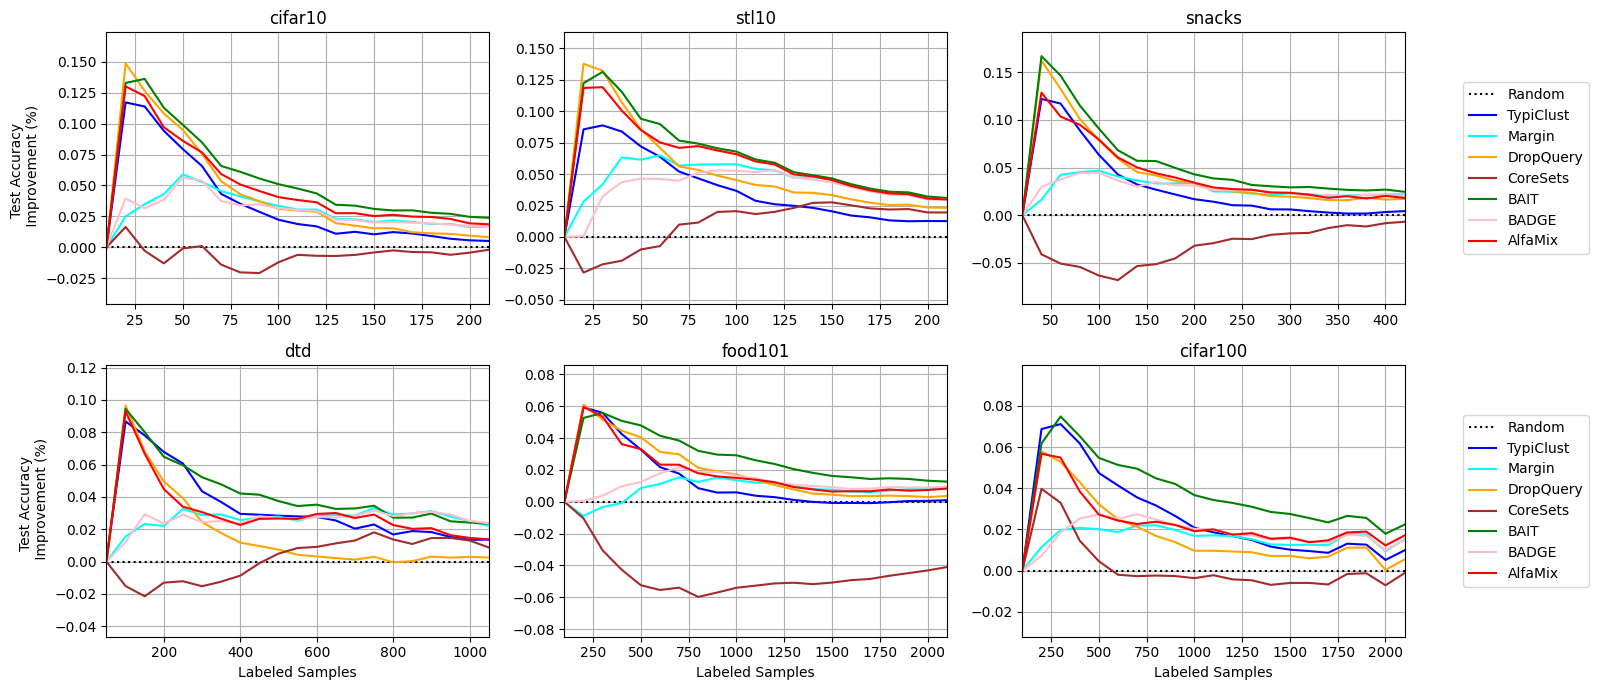

In [4]:
datasets = ['cifar10', 'stl10', 'snacks', 'dtd', 'food101', 'cifar100'] #, 'flowers102', 'imagenet']
acq_sizes = [10, 10, 20, 50, 100, 100] #, 40, 1000]
Q = {
    'alfamix' : {'c':'red', 'ls':'-', 'a':1, 'n':'AlfaMix'},
    'badge' : {'c':'pink', 'ls':'-', 'a':1, 'n':'BADGE'},
    'bait' : {'c':'green', 'ls':'-', 'a':1, 'n':'BAIT'},
    'coreset' : {'c':'brown', 'ls':'-', 'a':1, 'n':'CoreSets'},
    'dropquery' : {'c':'orange', 'ls':'-', 'a':1, 'n':'DropQuery'},
    'falcun' : {'c':'yellow', 'ls':'-', 'a':1, 'n':'FALCUN'},
    'margin' : {'c':'cyan', 'ls':'-', 'a':1, 'n':'Margin'},
    'typiclust' : {'c':'blue', 'ls':'-', 'a':1, 'n':'TypiClust'},
}

fig, ax = plt.subplots(nrows=2, ncols=3, tight_layout=True, figsize=(16, 7))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3, i%3])
    acqs = acq_sizes[i]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles=':', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 3 == 1:
        plt.xlabel('Labeled Samples')
    if i % 3 == 2:
        plt.legend(bbox_to_anchor=[1.5, 0.5], loc='center right')
    if i % 3 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
plt.show()

# Remarks

- Most promising strategies next to Random as a baseline are BAIT, DropQuery and TypiClust, which we use as the 4 strategies for the lazy oracle.
- ImageNet is currently not further evaluated as it is way to expensive on compute
- Flowers102 is also excluded from further experiments as we queried 50 samples for 20 cycles and it only has 1025 samples in total 
- We set the standard subset of the unlabeled pool of 10000 to limit the number of possible batches that are available, but does that make sense?

# Lazy Oracle

First method to test ist the classic lazy oracle using Random, BAIT, DropQuery and TypiClust as batch-proposers (just once).

In [5]:
# Load in results from lazy oracle
uri = 'sqlite:///perf_dal.db'
experiment_name = 'image_oracle_lazy_s'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments'.format(len(runs_strategies)))

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    run_per_strat[key].append(run)
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)

Found 60 experiments


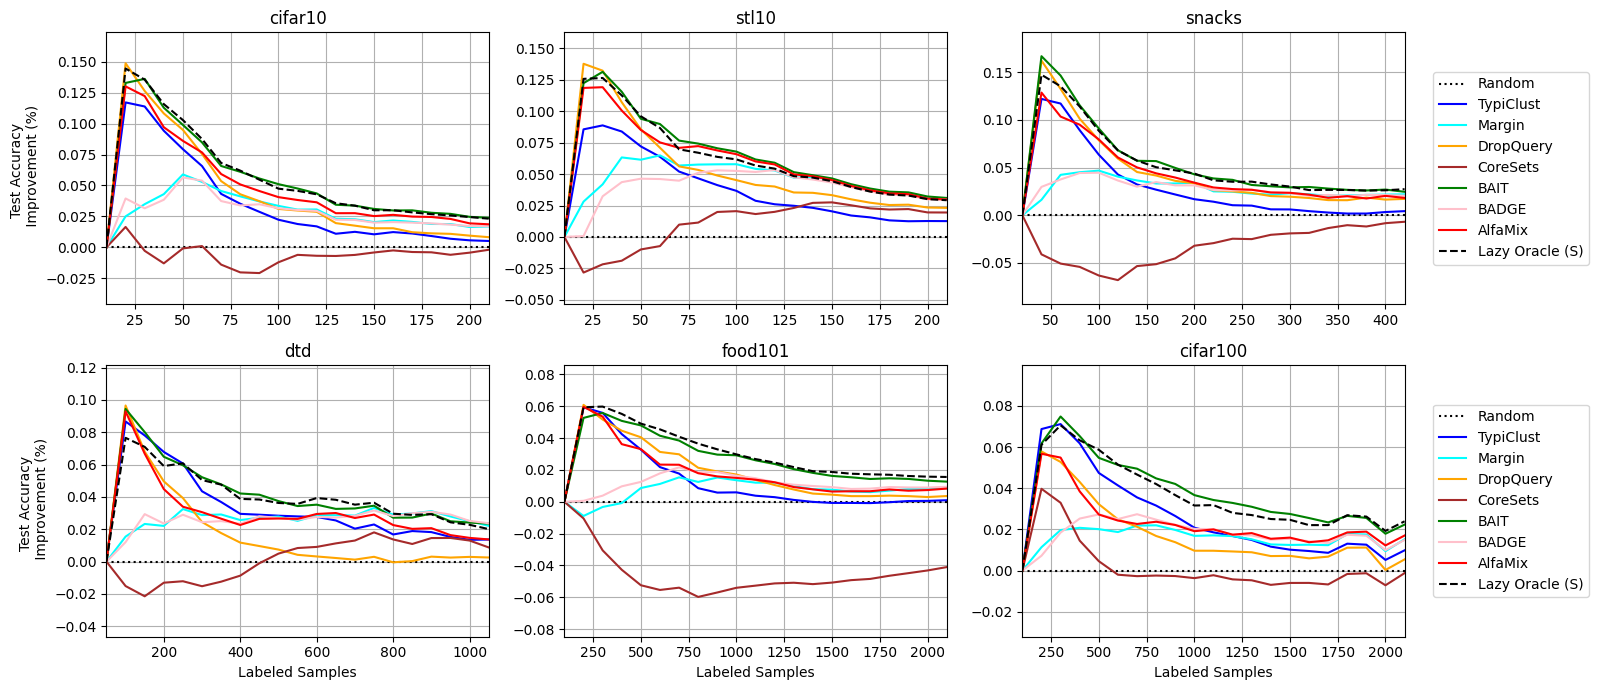

In [6]:
datasets = ['cifar10', 'stl10', 'snacks', 'dtd', 'food101', 'cifar100'] #, 'flowers102', 'imagenet']
acq_sizes = [10, 10, 20, 50, 100, 100] #, 40, 1000]
Q = {
    'alfamix' : {'c':'red', 'ls':'-', 'a':1, 'n':'AlfaMix'},
    'badge' : {'c':'pink', 'ls':'-', 'a':1, 'n':'BADGE'},
    'bait' : {'c':'green', 'ls':'-', 'a':1, 'n':'BAIT'},
    'coreset' : {'c':'brown', 'ls':'-', 'a':1, 'n':'CoreSets'},
    'dropquery' : {'c':'orange', 'ls':'-', 'a':1, 'n':'DropQuery'},
    'falcun' : {'c':'yellow', 'ls':'-', 'a':1, 'n':'FALCUN'},
    'margin' : {'c':'cyan', 'ls':'-', 'a':1, 'n':'Margin'},
    'typiclust' : {'c':'blue', 'ls':'-', 'a':1, 'n':'TypiClust'},
    'perf_dal_oracle' : {'c':'black', 'ls':'--', 'a':1, 'n':'Lazy Oracle (S)'},
}

fig, ax = plt.subplots(nrows=2, ncols=3, tight_layout=True, figsize=(16, 7))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3, i%3])
    acqs = acq_sizes[i]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles=':', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 3 == 1:
        plt.xlabel('Labeled Samples')
    if i % 3 == 2:
        plt.legend(bbox_to_anchor=[1.5, 0.5], loc='center right')
    if i % 3 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
plt.show()

# Remarks

